                                                    FNN with Keras higher order color indices predictions

In [61]:
from tensorflow import keras
import joblib
import pandas as pd

In [62]:
df_new = pd.read_csv(r"C:\Users\PIYUSH\Downloads\MyTable_2_TwinkleKashyap.csv")

print(df_new.head())
print(df_new.columns)

                 objid         u         g         r         i         z  \
0  1237671696060581716  23.67549  20.66940  19.22081  18.22113  17.70474   
1  1237668707303424749  21.43174  19.40755  18.49240  18.13505  17.94761   
2  1237668706229485848  21.85019  20.34860  19.69839  19.45158  19.40700   
3  1237668705155613223  22.01424  20.00161  19.17358  18.85867  18.58247   
4  1237668706766422345  17.68311  16.56997  16.18189  16.04864  15.99897   

   redshift  
0  0.000470  
1  0.000034  
2  0.000053  
3  0.000284  
4  0.000233  
Index(['objid', 'u', 'g', 'r', 'i', 'z', 'redshift'], dtype='object')


In [63]:
# Basic colors
df_new['u_g'] = df_new['u'] - df_new['g']
df_new['g_r'] = df_new['g'] - df_new['r']
df_new['r_i'] = df_new['r'] - df_new['i']
df_new['i_z'] = df_new['i'] - df_new['z']

# Higher-order colors
df_new['u_r'] = df_new['u'] - df_new['r']
df_new['g_i'] = df_new['g'] - df_new['i']
df_new['r_z'] = df_new['r'] - df_new['z']

In [64]:
model = keras.models.load_model("fnn_model_with_z.keras")
features = joblib.load("features_fnn_with_z.pkl")

In [65]:
df_input = df_new[features]

In [66]:
scaler = joblib.load("scaler_with_z.pkl")
df_input = scaler.transform(df_input)

In [67]:
# Probabilities
probs = model.predict(df_input)

# Class prediction
pred = probs.argmax(axis=1)

# Confidence
confidence = probs.max(axis=1)

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


In [68]:
df_new['predicted_class'] = pred
df_new['confidence'] = confidence

In [69]:
mapping = {0: 'Galaxy', 1: 'QSO', 2: 'Star'}  
df_new['predicted_class'] = df_new['predicted_class'].map(mapping)

In [70]:
print(df_new[['predicted_class', 'confidence']].head(10))
print(df_new['predicted_class'].value_counts())

  predicted_class  confidence
0            Star    0.999979
1            Star    0.999245
2            Star    0.997567
3            Star    0.998018
4            Star    0.999259
5            Star    0.999463
6            Star    0.999153
7            Star    0.999955
8            Star    0.999999
9          Galaxy    0.978944
predicted_class
Galaxy    75994
QSO       14184
Star       9822
Name: count, dtype: int64


In [71]:
print(df_new['confidence'].describe())

count    100000.000000
mean          0.988035
std           0.045145
min           0.500577
25%           0.995964
50%           0.998833
75%           0.999698
max           1.000000
Name: confidence, dtype: float64


In [72]:
high_conf = df_new[df_new['confidence'] > 0.9]
print(len(high_conf))

97062


In [73]:
df_new.groupby('predicted_class')['confidence'].mean()

predicted_class
Galaxy    0.988972
QSO       0.986517
Star      0.982977
Name: confidence, dtype: float32

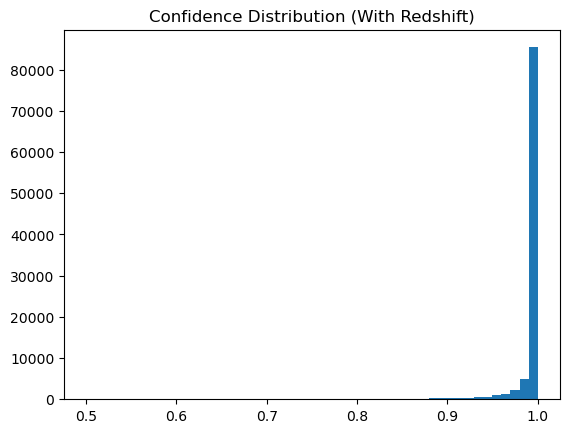

In [74]:
import matplotlib.pyplot as plt
plt.hist(df_new['confidence'], bins=50)
plt.title("Confidence Distribution (With Redshift)")
plt.show()

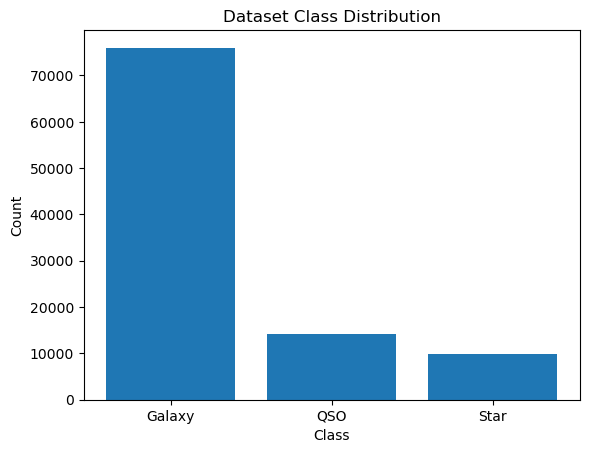

In [49]:
import matplotlib.pyplot as plt

counts = df_new['predicted_class'].value_counts()

# Fix order manually
labels = ['Galaxy', 'QSO', 'Star']
values = [counts[label] for label in labels]

plt.bar(labels, values)
plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

                                                                Without Redshift

In [50]:
model_no_z = keras.models.load_model("fnn_model_with_no_z.keras")
features_no_z = joblib.load("features_fnn_with_no_z.pkl")  

In [51]:
scaler_no_z = joblib.load("scaler_with_no_z.pkl")
df_input_no_z = df_new[features_no_z]
df_input_no_z = scaler_no_z.transform(df_input_no_z)

In [52]:
# Probabilities
probs_no_z = model_no_z.predict(df_input_no_z)

# Class prediction
pred_no_z = probs_no_z.argmax(axis=1)

# Confidence
confidence_no_z = probs_no_z.max(axis=1)

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


In [53]:
df_new['predicted_class'] = pred_no_z
df_new['confidence_no_z'] = confidence_no_z

In [54]:
mapping = {0: 'Galaxy', 1: 'QSO', 2: 'Star'}  
df_new['predicted_class'] = df_new['predicted_class'].map(mapping)

In [55]:
print(df_new[['predicted_class', 'confidence_no_z']].head(10))
print(df_new['predicted_class'].value_counts())

  predicted_class  confidence_no_z
0            Star         0.924642
1            Star         0.998584
2            Star         0.997462
3            Star         0.987626
4            Star         0.998718
5            Star         0.991356
6            Star         0.993312
7            Star         0.843181
8            Star         0.927894
9          Galaxy         0.997535
predicted_class
Galaxy    75814
QSO       12240
Star      11946
Name: count, dtype: int64


In [56]:
print(df_new['confidence_no_z'].describe())

count    100000.000000
mean          0.929873
std           0.116683
min           0.342362
25%           0.921980
50%           0.986132
75%           0.997068
max           1.000000
Name: confidence_no_z, dtype: float64


In [57]:
high_conf_no_z = df_new[df_new['confidence_no_z'] > 0.9]
print(len(high_conf_no_z))

78195


In [58]:
df_new.groupby('predicted_class')['confidence_no_z'].mean()

predicted_class
Galaxy    0.953501
QSO       0.857608
Star      0.853964
Name: confidence_no_z, dtype: float32

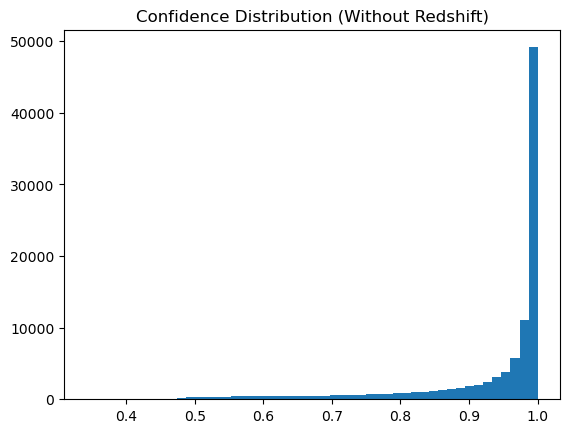

In [59]:

plt.hist(df_new['confidence_no_z'], bins=50)
plt.title("Confidence Distribution (Without Redshift)")
plt.show()

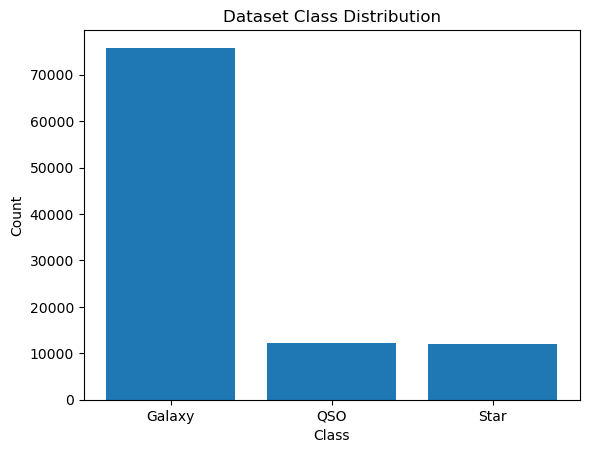

In [60]:
import matplotlib.pyplot as plt

counts = df_new['predicted_class'].value_counts()


labels = ['Galaxy', 'QSO', 'Star']
values = [counts[label] for label in labels]

plt.bar(labels, values)
plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()